In [ ]:
import pandas as pd
df = pd.read_csv("E Commerce Dataset.csv")

In [ ]:
# Create enhanced features BEFORE train/test split
print("Creating advanced features to improve model performance...")

# Make a copy to preserve original data
df_enhanced = df.copy()

# 1. INTERACTION FEATURES (capture combined effects)
print("\n1. Creating interaction features...")

# Tenure × Order patterns (loyalty + engagement)
if 'Tenure' in df_enhanced.columns and 'OrderCount' in df_enhanced.columns:
    df_enhanced['Tenure_x_OrderCount'] = df_enhanced['Tenure'] * df_enhanced['OrderCount']
    df_enhanced['Orders_per_Month'] = df_enhanced['OrderCount'] / (df_enhanced['Tenure'] + 1)  # +1 to avoid div by 0

# Satisfaction × Complain (satisfaction impact)
if 'SatisfactionScore' in df_enhanced.columns and 'Complain' in df_enhanced.columns:
    df_enhanced['Satisfaction_x_Complain'] = df_enhanced['SatisfactionScore'] * df_enhanced['Complain']

# Order amount patterns
if 'OrderAmountHikeFromlastYear' in df_enhanced.columns and 'OrderCount' in df_enhanced.columns:
    df_enhanced['AvgOrderValue'] = df_enhanced['OrderAmountHikeFromlastYear'] / (df_enhanced['OrderCount'] + 1)

# 2. BEHAVIORAL RATIOS (engagement metrics)
print("2. Creating behavioral ratios...")

# App engagement
if 'HourSpendOnApp' in df_enhanced.columns and 'Tenure' in df_enhanced.columns:
    df_enhanced['AppUsage_per_Month'] = df_enhanced['HourSpendOnApp'] / (df_enhanced['Tenure'] + 1)

# Cashback effectiveness
if 'CashbackAmount' in df_enhanced.columns and 'OrderCount' in df_enhanced.columns:
    df_enhanced['Cashback_per_Order'] = df_enhanced['CashbackAmount'] / (df_enhanced['OrderCount'] + 1)

# Coupon usage rate
if 'CouponUsed' in df_enhanced.columns and 'OrderCount' in df_enhanced.columns:
    df_enhanced['Coupon_Usage_Rate'] = df_enhanced['CouponUsed'] / (df_enhanced['OrderCount'] + 1)

# 3. RECENCY-FREQUENCY-MONETARY (RFM) STYLE FEATURES
print("3. Creating RFM-style features...")

# Days since last order (recency proxy)
if 'DaySinceLastOrder' in df_enhanced.columns:
    # Create recency bins
    df_enhanced['Recency_Category'] = pd.cut(
        df_enhanced['DaySinceLastOrder'],
        bins=[0, 5, 15, 30, 999],
        labels=['Very_Recent', 'Recent', 'Moderate', 'Long_Ago']
    )
    # Recency risk score (higher = more risk)
    df_enhanced['Recency_Risk'] = df_enhanced['DaySinceLastOrder'] / (df_enhanced['Tenure'] + 1)

# Order frequency category
if 'OrderCount' in df_enhanced.columns and 'Tenure' in df_enhanced.columns:
    df_enhanced['Order_Frequency_Category'] = pd.cut(
        df_enhanced['Orders_per_Month'],
        bins=[0, 1, 3, 10, 999],
        labels=['Low', 'Medium', 'High', 'Very_High']
    )

# 4. ENGAGEMENT SCORES (composite metrics)
print("4. Creating engagement scores...")

# Overall engagement score (0-100)
engagement_features = []
if 'HourSpendOnApp' in df_enhanced.columns:
    engagement_features.append('HourSpendOnApp')
if 'OrderCount' in df_enhanced.columns:
    engagement_features.append('OrderCount')
if 'CouponUsed' in df_enhanced.columns:
    engagement_features.append('CouponUsed')

if engagement_features:
    # Normalize each feature to 0-1 scale then average
    engagement_normalized = df_enhanced[engagement_features].copy()
    for col in engagement_features:
        max_val = engagement_normalized[col].max()
        if max_val > 0:
            engagement_normalized[col] = engagement_normalized[col] / max_val
    df_enhanced['Engagement_Score'] = engagement_normalized.mean(axis=1) * 100

# 5. RISK INDICATORS (red flags)
print("5. Creating risk indicators...")

# High-risk combination flags
if 'Complain' in df_enhanced.columns and 'SatisfactionScore' in df_enhanced.columns:
    df_enhanced['High_Risk_Flag'] = (
        (df_enhanced['Complain'] == 1) &
        (df_enhanced['SatisfactionScore'] <= 3)
    ).astype(int)

# Low engagement flag
if 'OrderCount' in df_enhanced.columns and 'Tenure' in df_enhanced.columns:
    df_enhanced['Low_Engagement_Flag'] = (
        df_enhanced['Orders_per_Month'] < 1
    ).astype(int)

# 6. TEMPORAL PATTERNS
print("6. Creating temporal patterns...")

if 'Tenure' in df_enhanced.columns:
    # Customer lifecycle stage
    df_enhanced['Customer_Lifecycle'] = pd.cut(
        df_enhanced['Tenure'],
        bins=[0, 1, 6, 12, 999],
        labels=['New', 'Growing', 'Mature', 'Loyal']
    )

# Count new features created
new_features = [col for col in df_enhanced.columns if col not in df.columns]
print(f"\nCreated {len(new_features)} new features:")
for feat in new_features[:15]:  # Show first 15
    print(f"  - {feat}")
if len(new_features) > 15:
    print(f"  ... and {len(new_features) - 15} more")

print(f"\nOriginal features: {df.shape[1]}")
print(f"Enhanced features: {df_enhanced.shape[1]}")
print(f"Improvement: +{len(new_features)} features ({len(new_features)/df.shape[1]*100:.1f}% increase)")

# Use enhanced dataframe for modeling
df = df_enhanced.copy()

Creating advanced features to improve model performance...

1. Creating interaction features...
2. Creating behavioral ratios...
3. Creating RFM-style features...
4. Creating engagement scores...
5. Creating risk indicators...
6. Creating temporal patterns...

Created 14 new features:
  - Tenure_x_OrderCount
  - Orders_per_Month
  - Satisfaction_x_Complain
  - AvgOrderValue
  - AppUsage_per_Month
  - Cashback_per_Order
  - Coupon_Usage_Rate
  - Recency_Category
  - Recency_Risk
  - Order_Frequency_Category
  - Engagement_Score
  - High_Risk_Flag
  - Low_Engagement_Flag
  - Customer_Lifecycle

Original features: 20
Enhanced features: 34
Improvement: +14 features (70.0% increase)


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    classification_report, confusion_matrix
)

from sklearn.inspection import permutation_importance

## 2. Load Dataset

In [ ]:
# Inspect the Excel file structure
xl_file = pd.ExcelFile('E Commerce Dataset.xlsx')
print(f" Sheet names in the workbook: {xl_file.sheet_names}\n")

# Load the actual E-Commerce data from the 'E Comm' sheet
print("=" * 80)
print("Loading E-Commerce Data...")
print("=" * 80)

df = pd.read_excel('E Commerce Dataset.xlsx', sheet_name='E Comm')

print(f" Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")

# Display first few rows
print("First 5 rows of the dataset:")
df.head()

 Sheet names in the workbook: ['Data Dict', 'E Comm']

Loading E-Commerce Data...
 Dataset loaded successfully!
Shape: 5,630 rows × 20 columns

First 5 rows of the dataset:


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [ ]:

# ---------------------------
# 2) Basic EDA
# ---------------------------
print("\n--- Column types ---")
print(df.dtypes)

print("\n--- Missing values (%) ---")
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0].head(30))

# Target distribution
TARGET_COL = "Churn"
print("\n--- Target distribution ---")
print(df[TARGET_COL].value_counts(dropna=False))
print(df[TARGET_COL].value_counts(normalize=True).rename("proportion"))

# Quick numeric summary
num_cols_all = df.select_dtypes(include=["number"]).columns.tolist()
print("\n--- Numeric summary (selected) ---")
print(df[num_cols_all].describe().T.head(20))

# Optional: correlations with churn for numeric columns (rough signal check)
if TARGET_COL in num_cols_all:
    corr = df[num_cols_all].corr(numeric_only=True)[TARGET_COL].sort_values(ascending=False)
    print("\n--- Numeric correlations with churn (rough) ---")
    print(corr)


--- Column types ---
CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice            object
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode            object
Gender                          object
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                object
SatisfactionScore                int64
MaritalStatus                   object
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                 float64
dtype: object

--- Missing values (%) ---
DaySinceLastOrder              5.452931
OrderAmountHikeFromlastYear    4.706927
Tenure                         4.689165
OrderCount                     4.582

## Advanced Feature Engineering for Better Results

Creating interaction features and domain-specific metrics can significantly improve model performance. We'll add:
1. **RFM-style features** (Recency, Frequency, Monetary patterns)
2. **Interaction features** (combinations that reveal hidden patterns)
3. **Behavioral ratios** (engagement metrics)
4. **Aggregated statistics** (per-category patterns)

# Task
Preprocess the `df` dataset by completing initial EDA and visualizing distributions, handling missing values, encoding categorical features, scaling numerical features, and splitting the data into training and testing sets, to prepare it for training Gradient Boosting, Logistic Regression, and XGBoost models.

## Complete Initial EDA and Visualize Distributions

### Subtask:
Building upon the existing EDA, generate visualizations such as histograms for numerical features, bar plots for categorical features, and explore relationships with the 'Churn' target variable using count plots or box plots. Ensure legends are provided for all plots.


**Reasoning**:
The first step is to import the necessary visualization libraries, `matplotlib.pyplot` and `seaborn`, to create the required plots.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries matplotlib.pyplot and seaborn imported successfully.")

Libraries matplotlib.pyplot and seaborn imported successfully.


In [ ]:
TARGET_COL = 'Churn'
CUSTOMER_ID_COL = 'CustomerID'

# Identify numerical columns, excluding CustomerID and Churn
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in [TARGET_COL, CUSTOMER_ID_COL]]

# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print(f"Numerical columns (excluding '{TARGET_COL}' and '{CUSTOMER_ID_COL}'): {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")

Numerical columns (excluding 'Churn' and 'CustomerID'): ['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']
Categorical columns: ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']


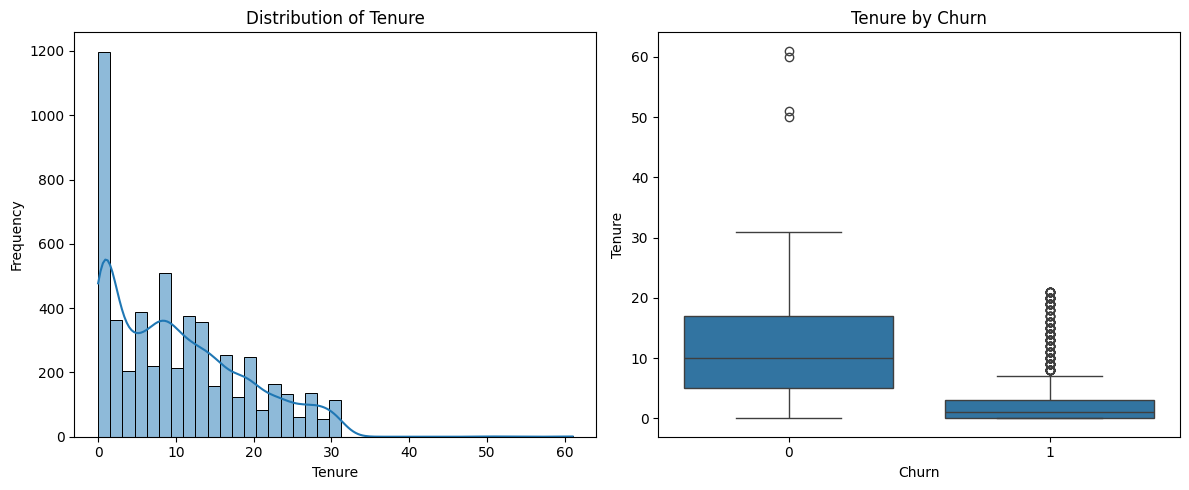

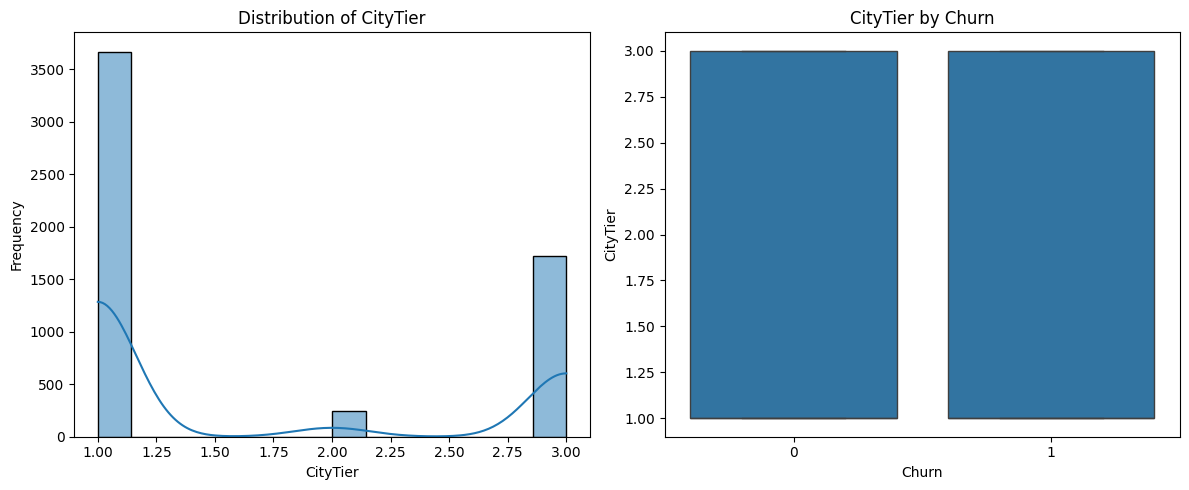

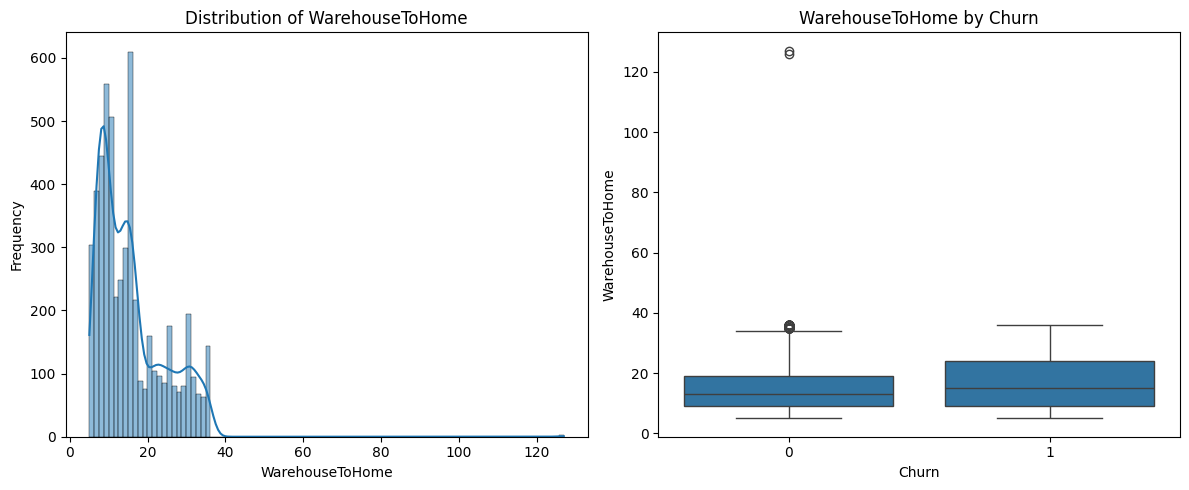

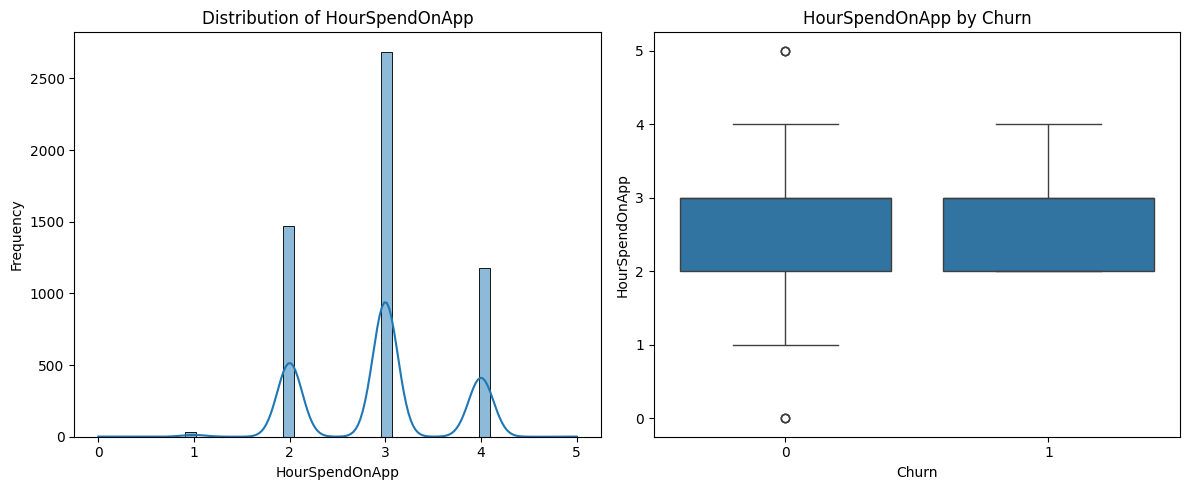

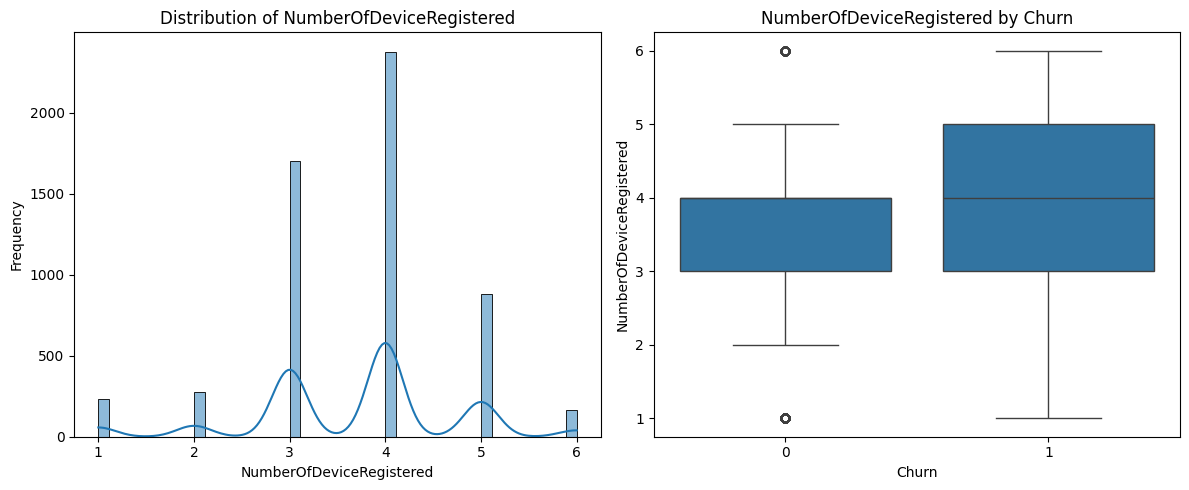

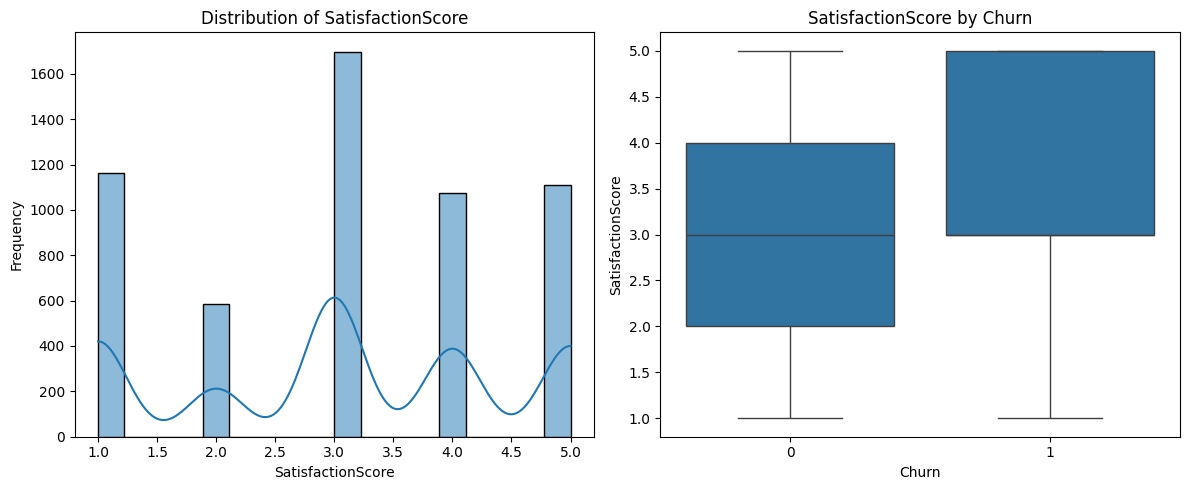

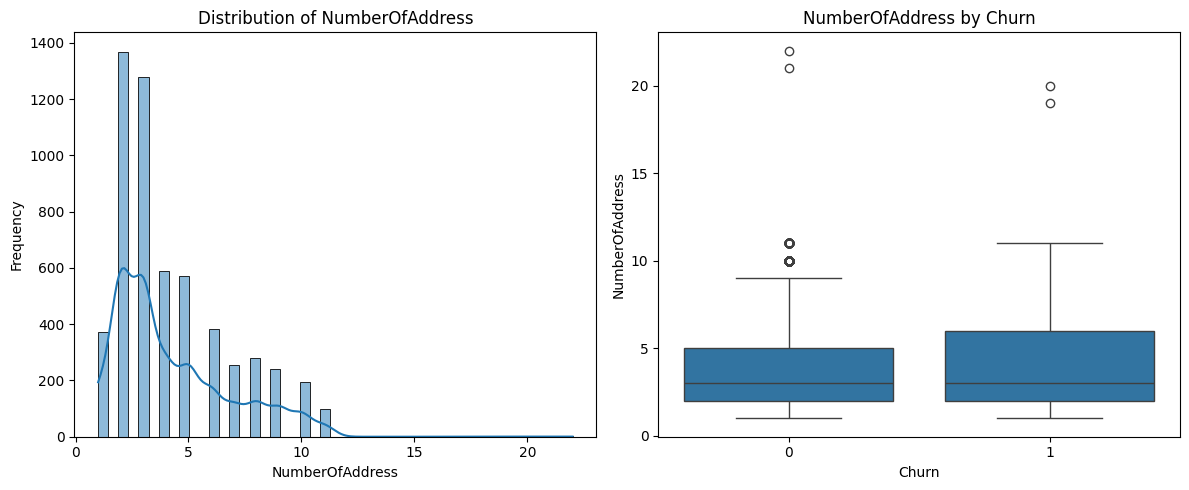

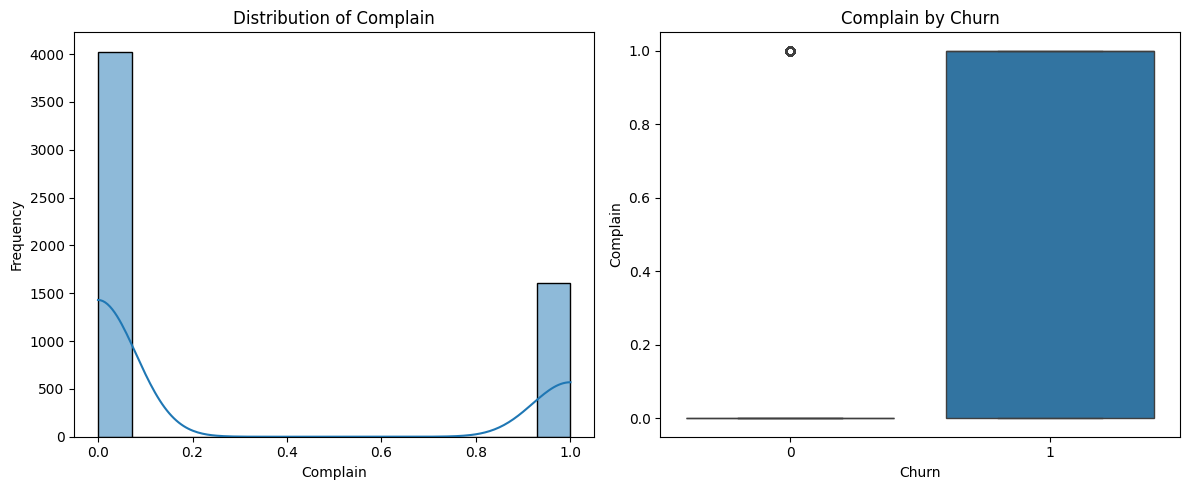

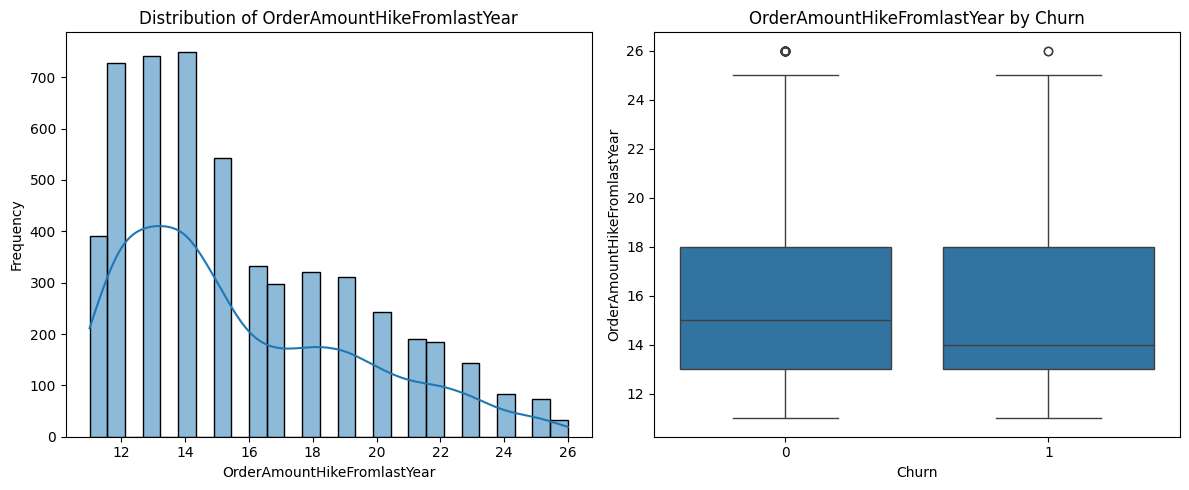

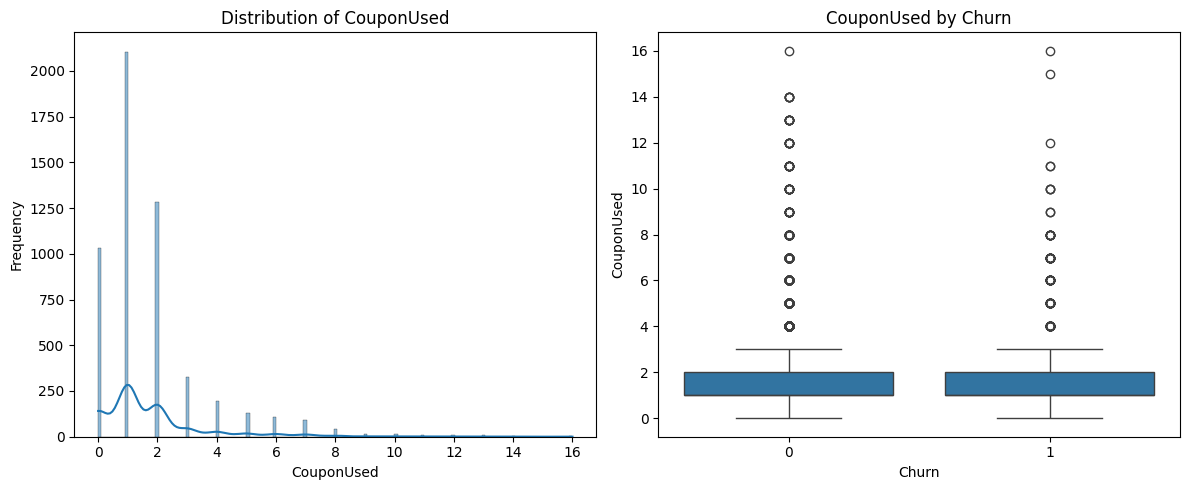

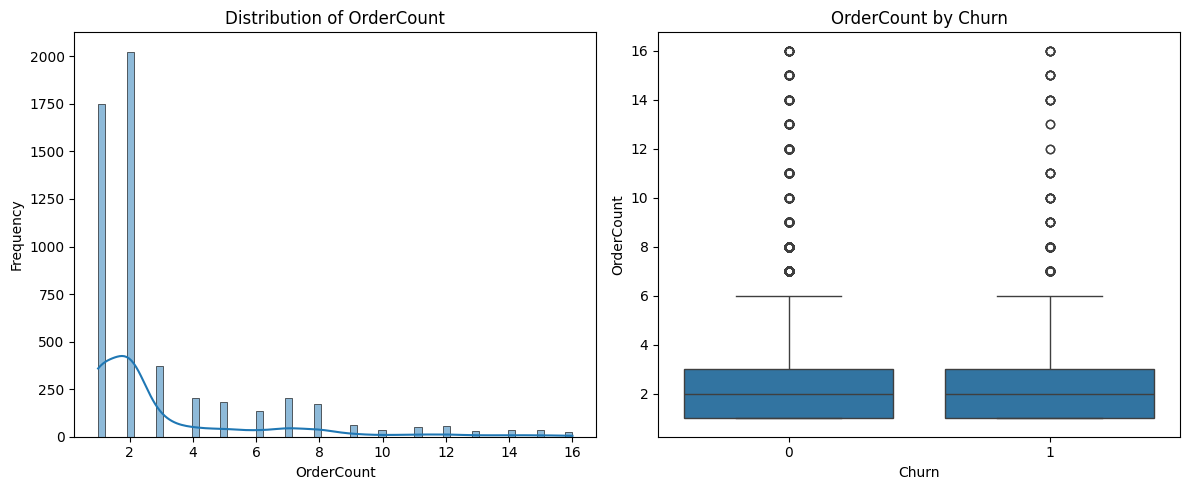

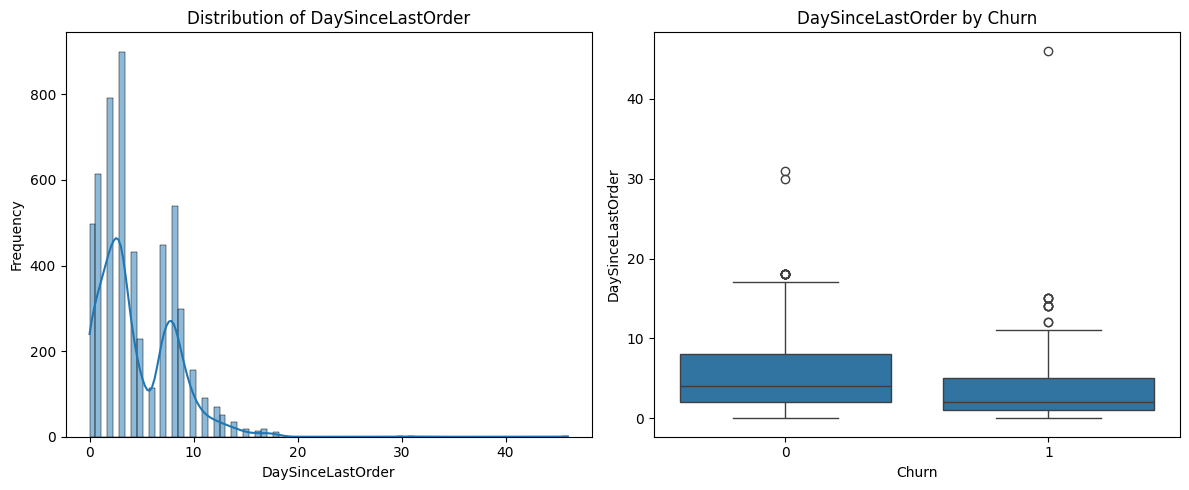

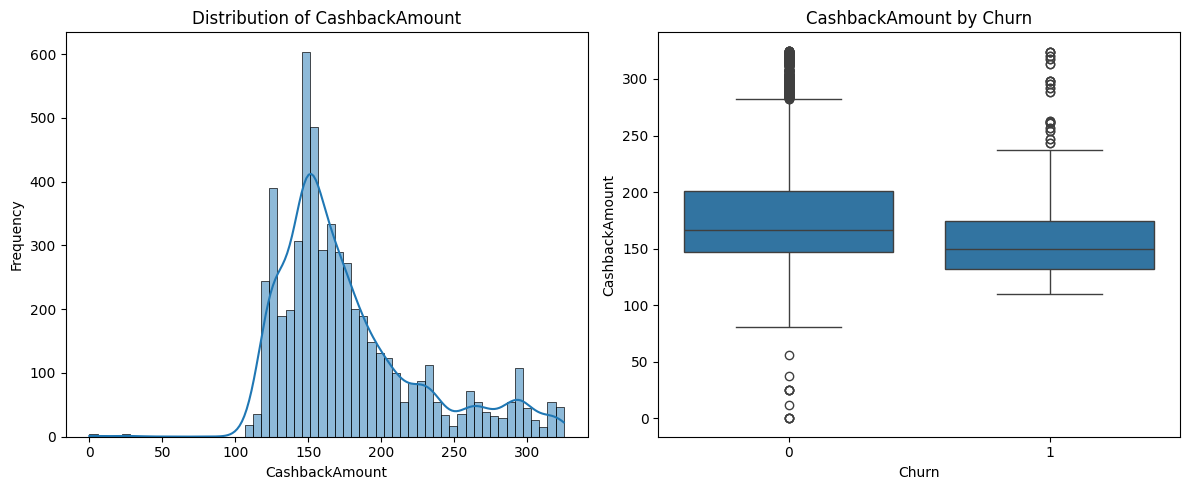

In [ ]:
for col in numerical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Histogram for distribution
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Distribution of {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')

    # Box plot for relationship with Churn
    sns.boxplot(x=TARGET_COL, y=col, data=df, ax=axes[1])
    axes[1].set_title(f'{col} by {TARGET_COL}')
    axes[1].set_xlabel(TARGET_COL)
    axes[1].set_ylabel(col)

    plt.tight_layout()
    plt.show()


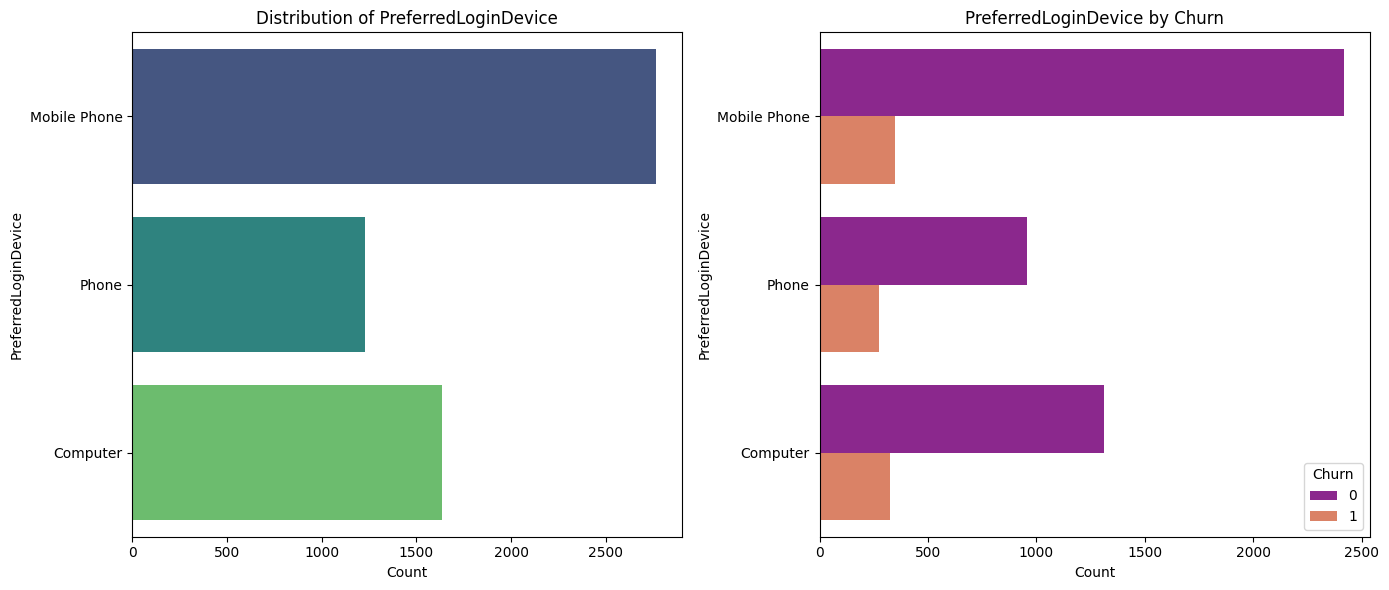

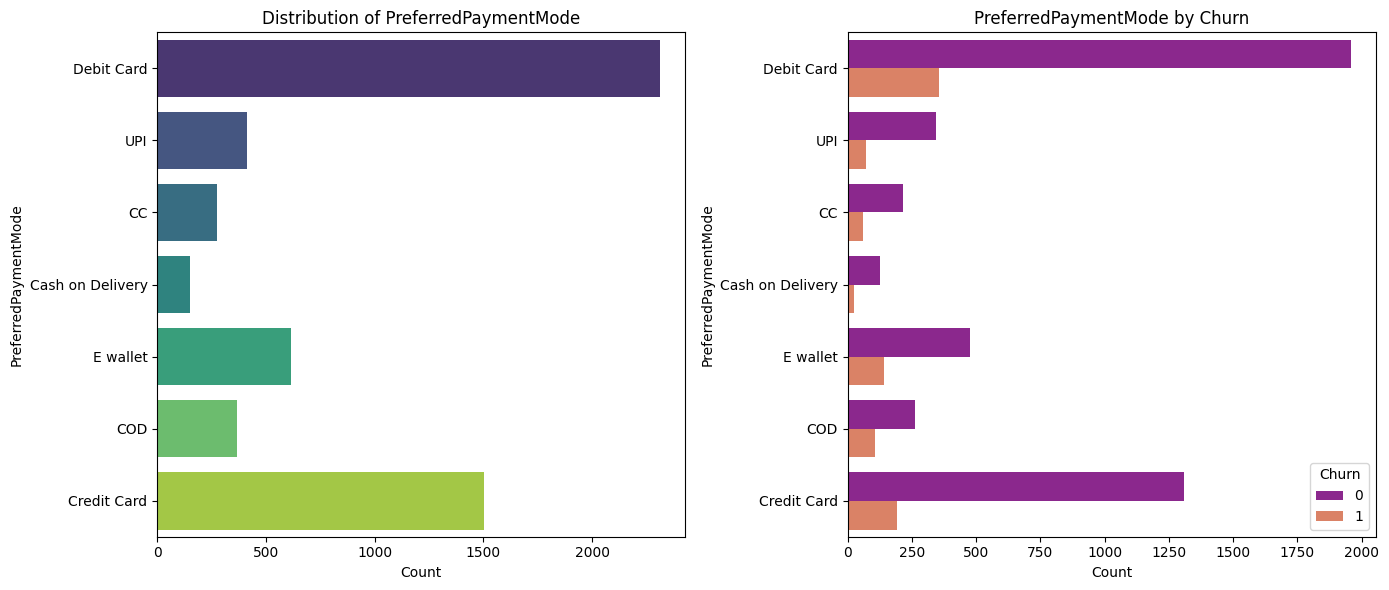

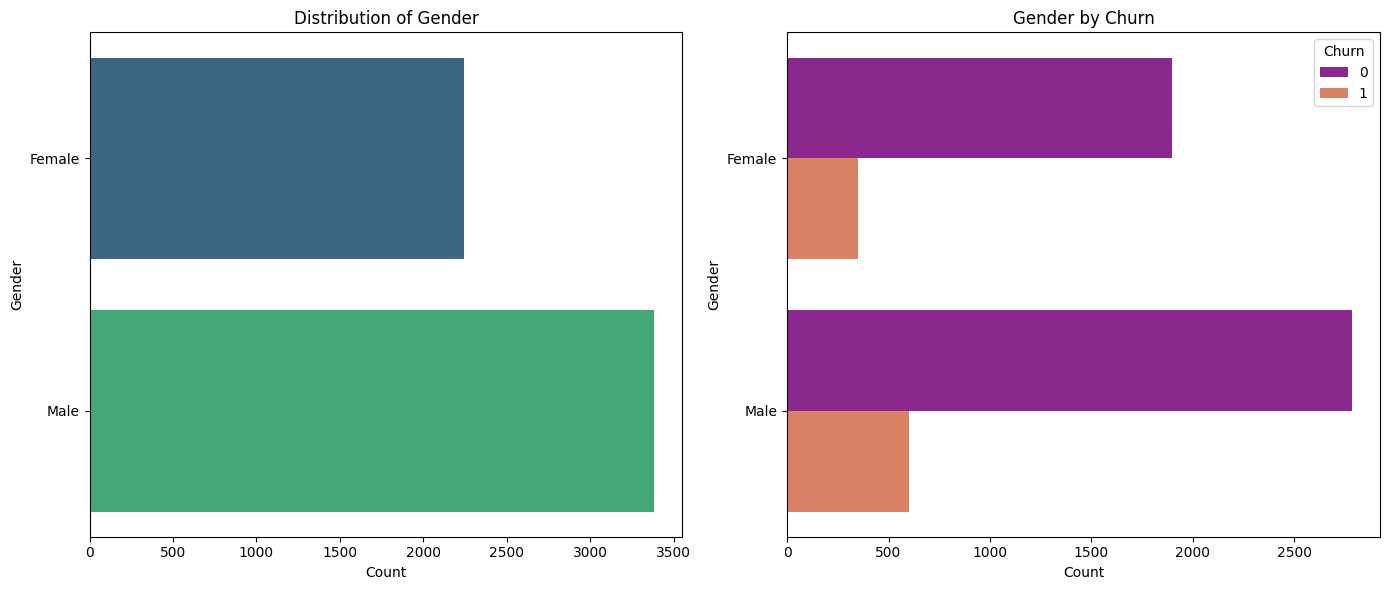

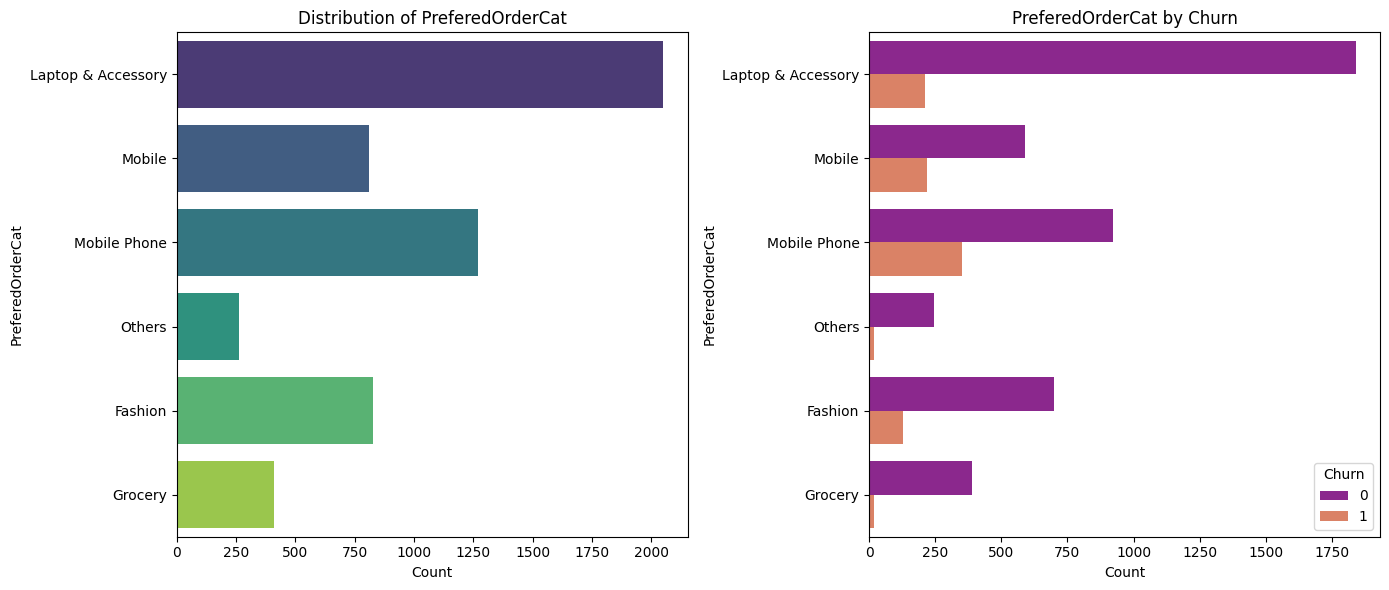

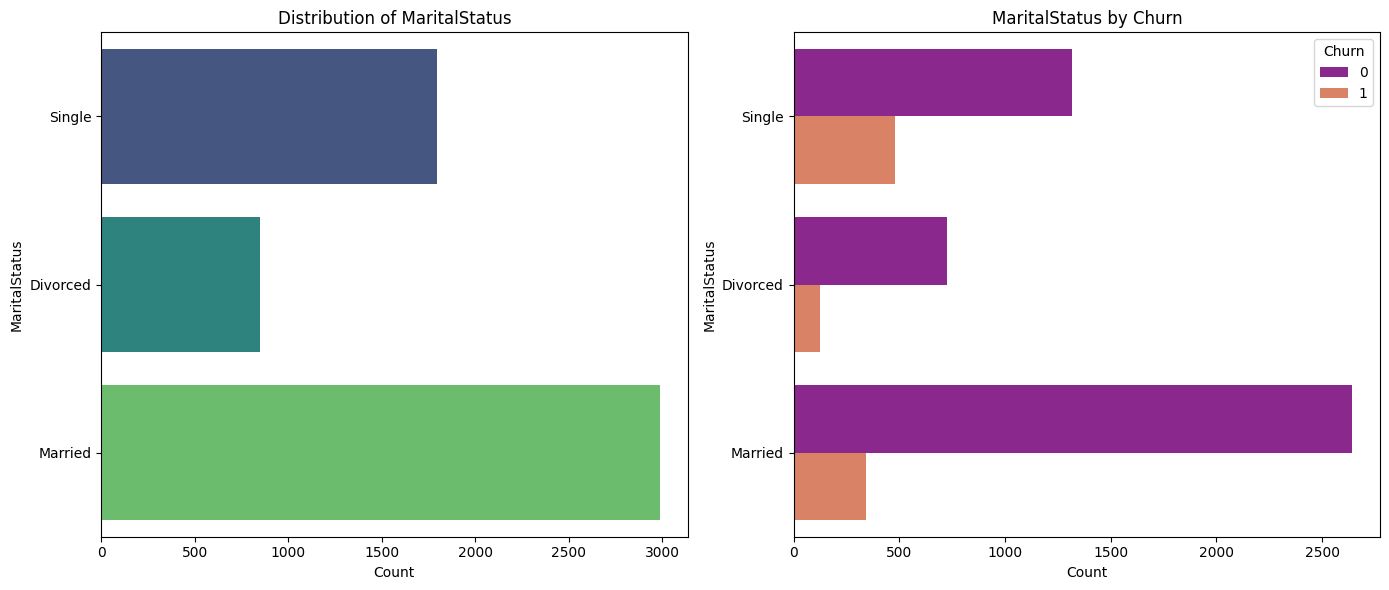

In [ ]:
for col in categorical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Bar plot for category distribution
    sns.countplot(y=col, data=df, ax=axes[0], palette='viridis')
    axes[0].set_title(f'Distribution of {col}')
    axes[0].set_xlabel('Count')
    axes[0].set_ylabel(col)

    # Count plot for relationship with Churn
    sns.countplot(y=col, hue=TARGET_COL, data=df, ax=axes[1], palette='plasma')
    axes[1].set_title(f'{col} by {TARGET_COL}')
    axes[1].set_xlabel('Count')
    axes[1].set_ylabel(col)
    axes[1].legend(title=TARGET_COL)

    plt.tight_layout()
    plt.show()

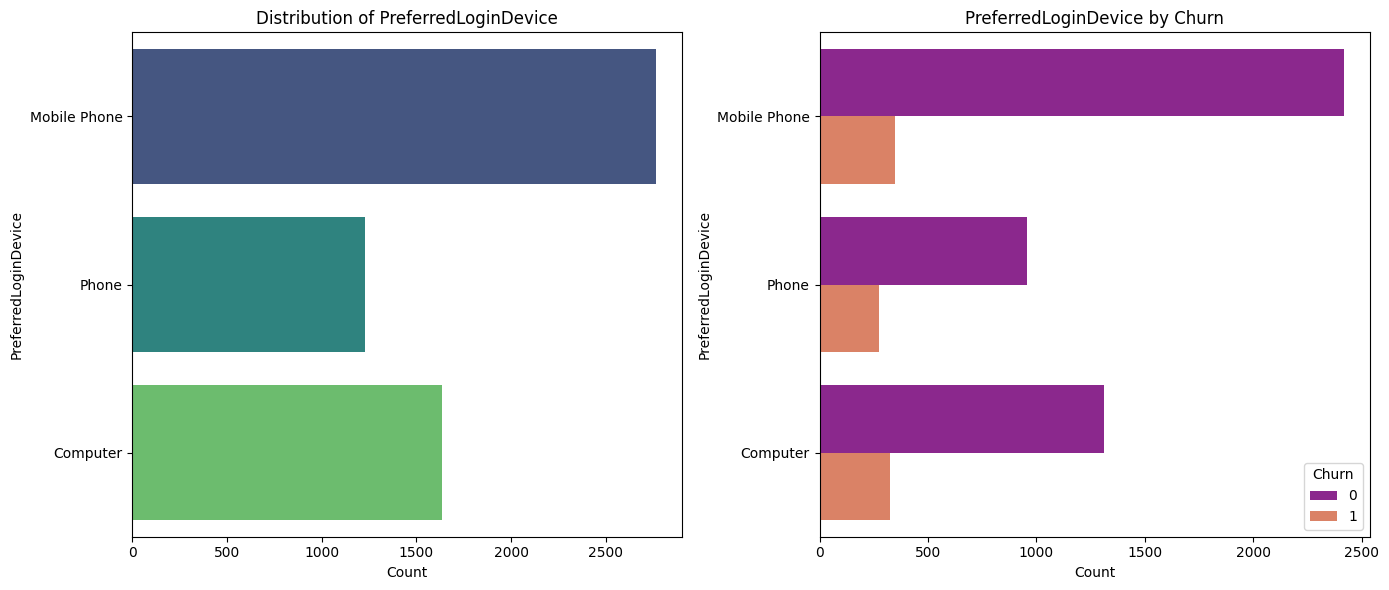

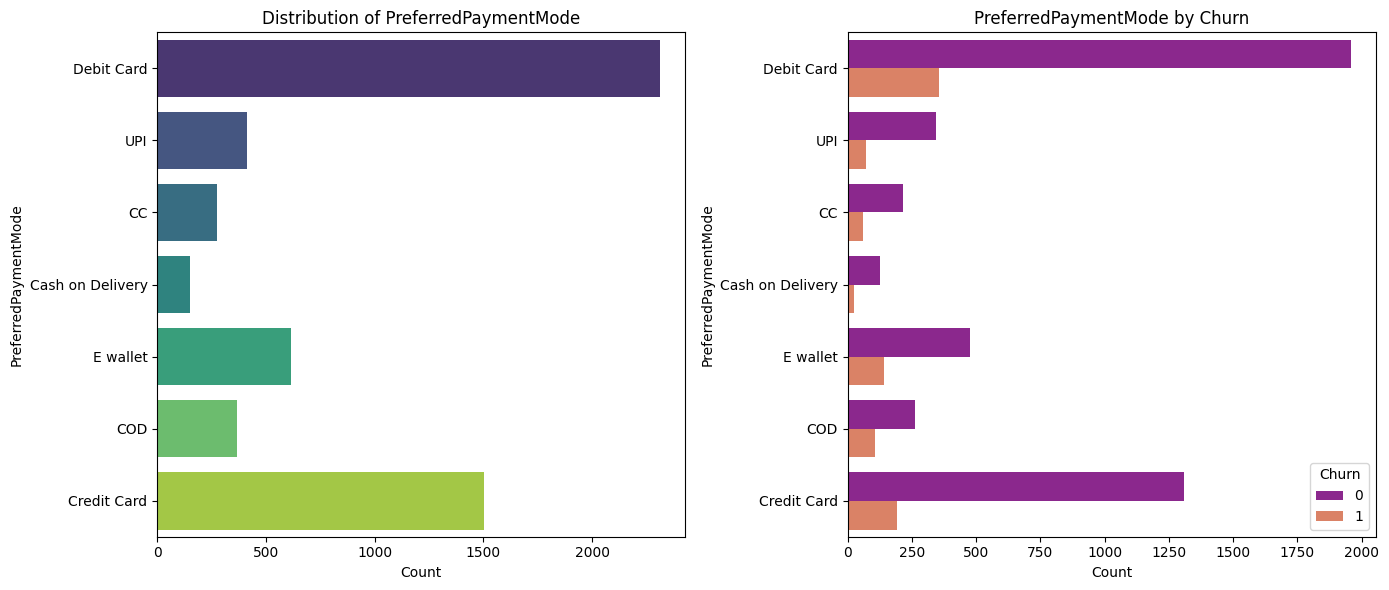

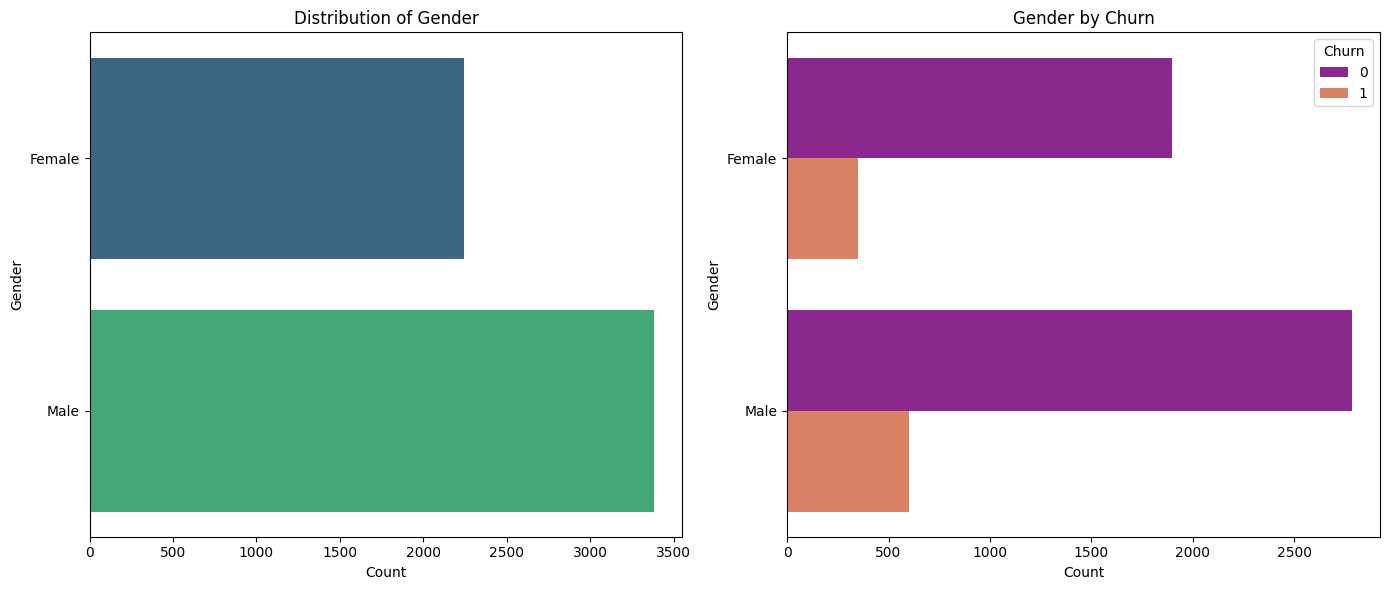

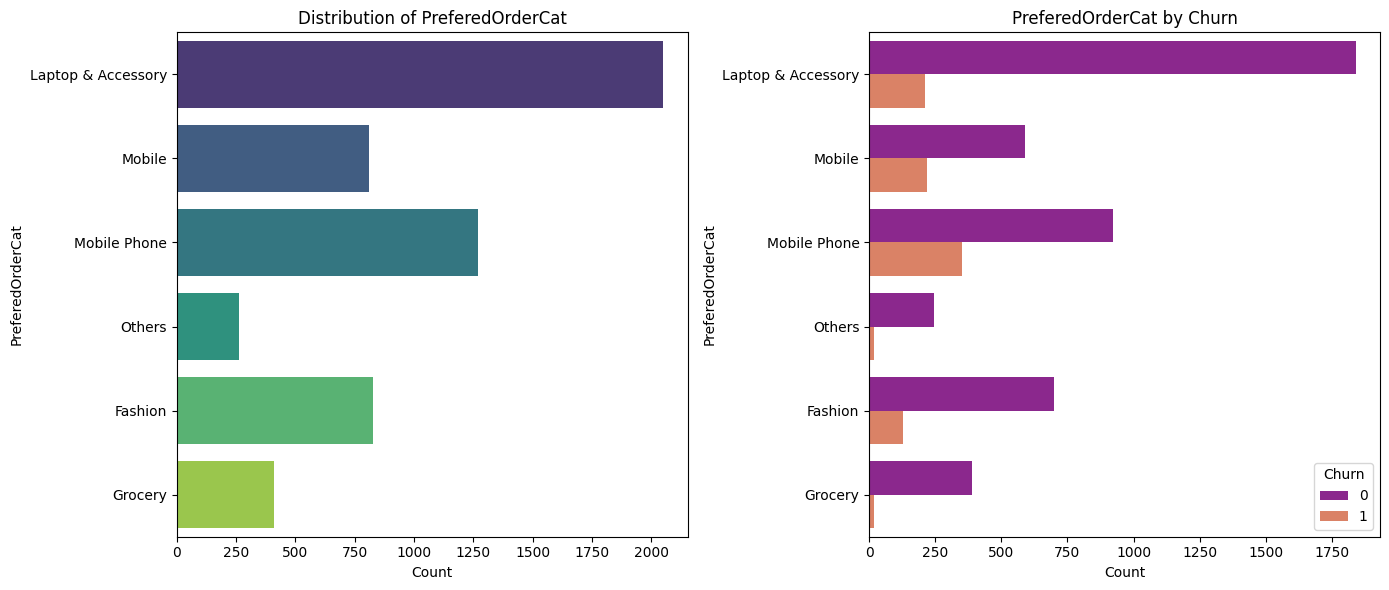

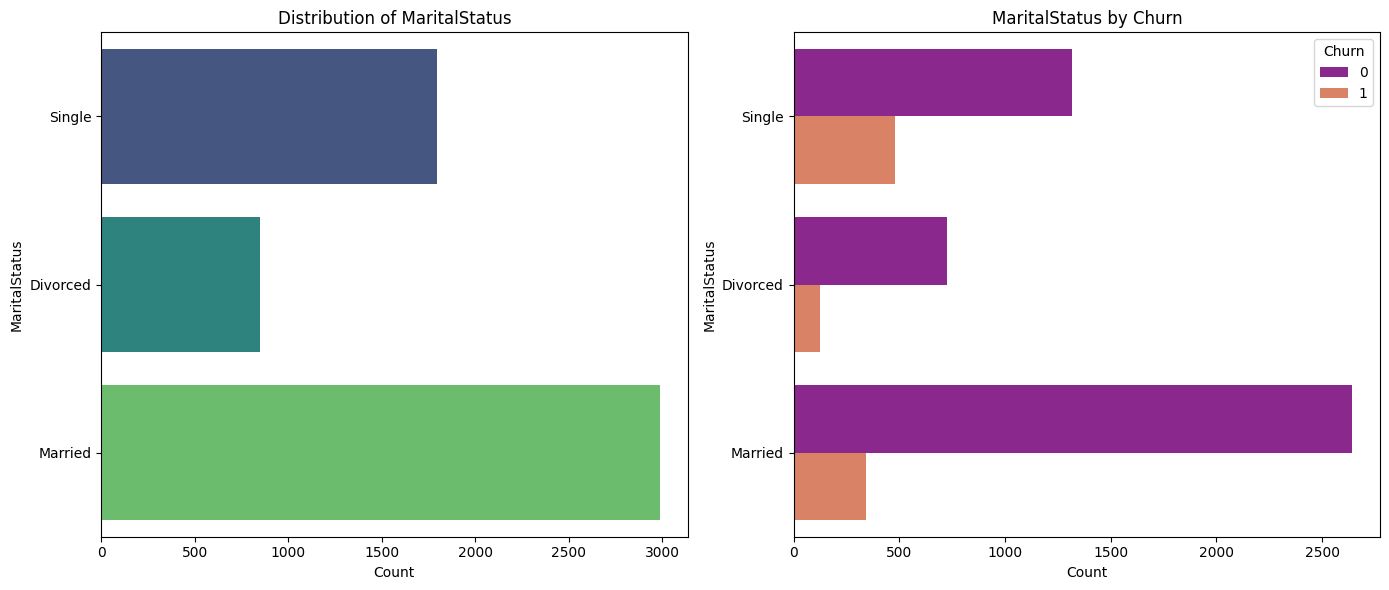

In [ ]:
for col in categorical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Bar plot for category distribution
    sns.countplot(y=col, data=df, ax=axes[0], palette='viridis')
    axes[0].set_title(f'Distribution of {col}')
    axes[0].set_xlabel('Count')
    axes[0].set_ylabel(col)

    # Count plot for relationship with Churn
    sns.countplot(y=col, hue=TARGET_COL, data=df, ax=axes[1], palette='plasma')
    axes[1].set_title(f'{col} by {TARGET_COL}')
    axes[1].set_xlabel('Count')
    axes[1].set_ylabel(col)
    axes[1].legend(title=TARGET_COL)

    plt.tight_layout()
    plt.show()

## Handle Missing Values

### Subtask:
Address missing values in the dataset by imputing numerical columns with their median values.


In [ ]:
missing_numerical_cols = [col for col in numerical_cols if df[col].isnull().any()]

print(f"Numerical columns with missing values: {missing_numerical_cols}")

Numerical columns with missing values: ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder']


In [ ]:
for col in missing_numerical_cols:
    median_value = df[col].median()
    df[col].fillna(median_value, inplace=True)
    print(f"Filled missing values in column '{col}' with median: {median_value}")

print("\n--- Verification of missing values after imputation ---")
print(df[missing_numerical_cols].isnull().sum())

Filled missing values in column 'Tenure' with median: 9.0
Filled missing values in column 'WarehouseToHome' with median: 14.0
Filled missing values in column 'HourSpendOnApp' with median: 3.0
Filled missing values in column 'OrderAmountHikeFromlastYear' with median: 15.0
Filled missing values in column 'CouponUsed' with median: 1.0
Filled missing values in column 'OrderCount' with median: 2.0
Filled missing values in column 'DaySinceLastOrder' with median: 3.0

--- Verification of missing values after imputation ---
Tenure                         0
WarehouseToHome                0
HourSpendOnApp                 0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
dtype: int64


## Process Categorical Features

### Subtask:
Identify and encode categorical features using appropriate methods like OneHotEncoder, preparing them for machine learning models.


In [ ]:
print("--- Missing values in categorical columns before imputation ---")
print(df[categorical_cols].isnull().sum())

for col in categorical_cols:
    if df[col].isnull().any():
        mode_value = df[col].mode()[0]
        df[col].fillna(mode_value, inplace=True)
        print(f"Filled missing values in categorical column '{col}' with mode: {mode_value}")

print("\n--- Missing values in categorical columns after imputation ---")
print(df[categorical_cols].isnull().sum())

--- Missing values in categorical columns before imputation ---
PreferredLoginDevice    0
PreferredPaymentMode    0
Gender                  0
PreferedOrderCat        0
MaritalStatus           0
dtype: int64

--- Missing values in categorical columns after imputation ---
PreferredLoginDevice    0
PreferredPaymentMode    0
Gender                  0
PreferedOrderCat        0
MaritalStatus           0
dtype: int64


In [ ]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Apply one-hot encoding
encoded_features = encoder.fit_transform(df[categorical_cols])

# Create a DataFrame from the encoded features
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_cols), index=df.index)

# Drop original categorical columns from df
df = df.drop(columns=categorical_cols)

# Concatenate the original df with the new encoded features DataFrame
df = pd.concat([df, encoded_df], axis=1)

print("Categorical features successfully one-hot encoded and integrated into the DataFrame.")
print("New DataFrame head:")
print(df.head())

Categorical features successfully one-hot encoded and integrated into the DataFrame.
New DataFrame head:
   CustomerID  Churn  Tenure  CityTier  WarehouseToHome  HourSpendOnApp  \
0       50001      1     4.0         3              6.0             3.0   
1       50002      1     9.0         1              8.0             3.0   
2       50003      1     9.0         1             30.0             2.0   
3       50004      1     0.0         3             15.0             2.0   
4       50005      1     0.0         1             12.0             3.0   

   NumberOfDeviceRegistered  SatisfactionScore  NumberOfAddress  Complain  \
0                         3                  2                9         1   
1                         4                  3                7         1   
2                         4                  3                6         1   
3                         4                  5                8         0   
4                         3                  5             

## Scale Numerical Features

### Subtask:
Scale the numerical features in the `df` dataset using `StandardScaler` to normalize their ranges.

In [ ]:
TARGET_COL = 'Churn'
CUSTOMER_ID_COL = 'CustomerID'

# Identify numerical columns to be scaled
# Exclude 'CustomerID' and 'Churn' as they are not features to be scaled
numerical_cols_to_scale = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols_to_scale = [col for col in numerical_cols_to_scale if col not in [TARGET_COL, CUSTOMER_ID_COL]]

print(f"Numerical columns identified for scaling: {numerical_cols_to_scale}")

Numerical columns identified for scaling: ['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'PreferredLoginDevice_Computer', 'PreferredLoginDevice_Mobile Phone', 'PreferredLoginDevice_Phone', 'PreferredPaymentMode_CC', 'PreferredPaymentMode_COD', 'PreferredPaymentMode_Cash on Delivery', 'PreferredPaymentMode_Credit Card', 'PreferredPaymentMode_Debit Card', 'PreferredPaymentMode_E wallet', 'PreferredPaymentMode_UPI', 'Gender_Female', 'Gender_Male', 'PreferedOrderCat_Fashion', 'PreferedOrderCat_Grocery', 'PreferedOrderCat_Laptop & Accessory', 'PreferedOrderCat_Mobile', 'PreferedOrderCat_Mobile Phone', 'PreferedOrderCat_Others', 'MaritalStatus_Divorced', 'MaritalStatus_Married', 'MaritalStatus_Single']


In [ ]:
scaler = StandardScaler()
df[numerical_cols_to_scale] = scaler.fit_transform(df[numerical_cols_to_scale])

print("Numerical features successfully scaled using StandardScaler.")
print("New DataFrame head with scaled features:")
print(df[numerical_cols_to_scale].head())

Numerical features successfully scaled using StandardScaler.
New DataFrame head with scaled features:
     Tenure  CityTier  WarehouseToHome  HourSpendOnApp  \
0 -0.733989  1.469771        -1.146379        0.092654   
1 -0.135704 -0.715286        -0.906721        0.092654   
2 -0.135704 -0.715286         1.729519       -1.324850   
3 -1.212618  1.469771        -0.067917       -1.324850   
4 -1.212618 -0.715286        -0.427405        0.092654   

   NumberOfDeviceRegistered  SatisfactionScore  NumberOfAddress  Complain  \
0                  -0.67290          -0.772992         1.852616  1.584290   
1                   0.30375          -0.048392         1.078430  1.584290   
2                   0.30375          -0.048392         0.691336  1.584290   
3                   0.30375           1.400807         1.465523 -0.631198   
4                  -0.67290           1.400807        -0.469944 -0.631198   

   OrderAmountHikeFromlastYear  CouponUsed  ...  Gender_Male  \
0                    -

## Split Data into Training and Testing Sets

### Subtask:
Split the preprocessed `df` dataset into training and testing sets using `train_test_split` from `sklearn.model_selection`. Ensure that the target variable 'Churn' is used for stratification to maintain the proportion of churned and non-churned customers in both sets.

In [ ]:
X = df.drop(columns=[TARGET_COL, CUSTOMER_ID_COL])
y = df[TARGET_COL]

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

Shape of features (X): (5630, 34)
Shape of target (y): (5630,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\n--- Target distribution in training set ---")
print(y_train.value_counts(normalize=True))

print("\n--- Target distribution in test set ---")
print(y_test.value_counts(normalize=True))

X_train shape: (4504, 34)
X_test shape: (1126, 34)
y_train shape: (4504,)
y_test shape: (1126,)

--- Target distribution in training set ---
Churn
0    0.831705
1    0.168295
Name: proportion, dtype: float64

--- Target distribution in test set ---
Churn
0    0.831261
1    0.168739
Name: proportion, dtype: float64


## Final Task

### Subtask:
Confirm that the dataset is fully preprocessed and ready for training Gradient Boosting, Logistic Regression, and XGBoost models, summarizing the steps taken.


# Task
Train a Logistic Regression model on the preprocessed training data (`X_train`, `y_train`), and evaluate its performance on the test set (`X_test`, `y_test`) using ROC AUC, Average Precision Score, classification report, and confusion matrix.

## Train and Evaluate Logistic Regression Model

### Subtask:
Train a Logistic Regression model on the preprocessed training data (`X_train`, `y_train`). Evaluate its performance on the test set (`X_test`, `y_test`) using ROC AUC, Average Precision Score, and display a classification report and confusion matrix. This will serve as a baseline for comparison.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix

log_reg = LogisticRegression(random_state=42, solver='liblinear')
log_reg.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


# Task
**Reasoning**:
Now that the Logistic Regression model has been trained, the next step is to evaluate its performance on the test set (`X_test`, `y_test`). I will calculate the predicted probabilities for the positive class to compute ROC AUC and Average Precision Score, and predict the class labels to generate the classification report and confusion matrix.

**Command**:
```python
# Predict probabilities for the positive class (Churn=1)
y_pred_proba_log_reg = log_reg.predict_proba(X_test)[:, 1]

# Predict class labels
y_pred_log_reg = log_reg.predict(X_test)

# Calculate evaluation metrics
roc_auc_log_reg = roc_auc_score(y_test, y_pred_proba_log_reg)
avg_precision_log_reg = average_precision_score(y_test, y_pred_proba_log_reg)
class_report_log_reg = classification_report(y_test, y_pred_log_reg)
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)

print(f"Logistic Regression ROC AUC: {roc_auc_log_reg:.4f}")
print(f"Logistic Regression Average Precision Score: {avg_precision_log_reg:.4f}")
print("\nLogistic Regression Classification Report:")
print(class_report_log_reg)
print("\nLogistic Regression Confusion Matrix:")
print(conf_matrix_log_reg)
```

## Train and Evaluate Random Forest Classifier

### Subtask:
Initialize, train, and evaluate a Random Forest Classifier on the preprocessed training data (`X_train`, `y_train`). Report its performance using ROC AUC, Average Precision Score, a classification report, and a confusion matrix on the test set (`X_test`, `y_test`).


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train, y_train)

print("Random Forest Classifier trained successfully.")

Random Forest Classifier trained successfully.


In [ ]:
y_pred_proba_rf = rf_classifier.predict_proba(X_test)[:, 1]
y_pred_rf = rf_classifier.predict(X_test)

roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
avg_precision_rf = average_precision_score(y_test, y_pred_proba_rf)
class_report_rf = classification_report(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

print(f"Random Forest Classifier ROC AUC: {roc_auc_rf:.4f}")
print(f"Random Forest Classifier Average Precision Score: {avg_precision_rf:.4f}")
print("\nRandom Forest Classifier Classification Report:")
print(class_report_rf)
print("\nRandom Forest Classifier Confusion Matrix:")
print(conf_matrix_rf)

Random Forest Classifier ROC AUC: 0.9989
Random Forest Classifier Average Precision Score: 0.9946

Random Forest Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       936
           1       1.00      0.86      0.92       190

    accuracy                           0.98      1126
   macro avg       0.99      0.93      0.95      1126
weighted avg       0.98      0.98      0.98      1126


Random Forest Classifier Confusion Matrix:
[[936   0]
 [ 27 163]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix
import numpy as np

# Define parameter distribution
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

# Base model
rf_classifier = RandomForestClassifier(random_state=42)

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=rf_classifier,
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit tuning
random_search.fit(X_train, y_train)

# Best model after tuning
best_rf = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)

# Predictions using tuned model
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]
y_pred_rf = best_rf.predict(X_test)

# Evaluation
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
avg_precision_rf = average_precision_score(y_test, y_pred_proba_rf)
class_report_rf = classification_report(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

print(f"Tuned Random Forest ROC AUC: {roc_auc_rf:.4f}")
print(f"Tuned Random Forest Average Precision Score: {avg_precision_rf:.4f}")
print("\nTuned Random Forest Classification Report:")
print(class_report_rf)
print("\nTuned Random Forest Confusion Matrix:")
print(conf_matrix_rf)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': False}
Tuned Random Forest ROC AUC: 0.9996
Tuned Random Forest Average Precision Score: 0.9981

Tuned Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       936
           1       0.99      0.94      0.97       190

    accuracy                           0.99      1126
   macro avg       0.99      0.97      0.98      1126
weighted avg       0.99      0.99      0.99      1126


Tuned Random Forest Confusion Matrix:
[[935   1]
 [ 11 179]]


## Train and Evaluate Gradient Boosting Classifier

### Subtask:
Initialize, train, and evaluate a scikit-learn HistGradientBoostingClassifier on the preprocessed training data (`X_train`, `y_train`). Report its performance using ROC AUC, Average Precision Score, a classification report, and a confusion matrix on the test set (`X_test`, `y_test`).


In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

# Initialize and train the HistGradientBoostingClassifier
gb_classifier = HistGradientBoostingClassifier(random_state=42)
gb_classifier.fit(X_train, y_train)

print("HistGradientBoostingClassifier trained successfully.")

HistGradientBoostingClassifier trained successfully.


In [ ]:
y_pred_proba_gb = gb_classifier.predict_proba(X_test)[:, 1]
y_pred_gb = gb_classifier.predict(X_test)

roc_auc_gb = roc_auc_score(y_test, y_pred_proba_gb)
avg_precision_gb = average_precision_score(y_test, y_pred_proba_gb)
class_report_gb = classification_report(y_test, y_pred_gb)
conf_matrix_gb = confusion_matrix(y_test, y_pred_gb)

print(f"HistGradientBoostingClassifier ROC AUC: {roc_auc_gb:.4f}")
print(f"HistGradientBoostingBoosting Average Precision Score: {avg_precision_gb:.4f}")
print("\nHistGradientBoostingClassifier Classification Report:")
print(class_report_gb)
print("\nHistGradientBoostingClassifier Confusion Matrix:")
print(conf_matrix_gb)

HistGradientBoostingClassifier ROC AUC: 0.9981
HistGradientBoostingBoosting Average Precision Score: 0.9915

HistGradientBoostingClassifier Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       936
           1       0.98      0.93      0.96       190

    accuracy                           0.99      1126
   macro avg       0.98      0.96      0.97      1126
weighted avg       0.99      0.99      0.99      1126


HistGradientBoostingClassifier Confusion Matrix:
[[933   3]
 [ 13 177]]


In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix
import numpy as np

# Define parameter distribution
param_dist = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_iter': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_leaf': [20, 30, 50],
    'l2_regularization': [0.0, 0.1, 1.0],
    'max_bins': [255, 200]
}

# Base model
gb_classifier = HistGradientBoostingClassifier(random_state=42)

# Randomized Search
random_search_gb = RandomizedSearchCV(
    estimator=gb_classifier,
    param_distributions=param_dist,
    n_iter=40,
    scoring='roc_auc',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit tuning
random_search_gb.fit(X_train, y_train)

# Best model after tuning
best_gb = random_search_gb.best_estimator_

print("Best Parameters:", random_search_gb.best_params_)

# Predictions using tuned model
y_pred_proba_gb = best_gb.predict_proba(X_test)[:, 1]
y_pred_gb = best_gb.predict(X_test)

# Evaluation
roc_auc_gb = roc_auc_score(y_test, y_pred_proba_gb)
avg_precision_gb = average_precision_score(y_test, y_pred_proba_gb)
class_report_gb = classification_report(y_test, y_pred_gb)
conf_matrix_gb = confusion_matrix(y_test, y_pred_gb)

print(f"Tuned HistGradientBoosting ROC AUC: {roc_auc_gb:.4f}")
print(f"Tuned HistGradientBoosting Average Precision Score: {avg_precision_gb:.4f}")
print("\nTuned HistGradientBoosting Classification Report:")
print(class_report_gb)
print("\nTuned HistGradientBoosting Confusion Matrix:")
print(conf_matrix_gb)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Parameters: {'min_samples_leaf': 30, 'max_iter': 300, 'max_depth': 20, 'max_bins': 255, 'learning_rate': 0.2, 'l2_regularization': 0.0}
Tuned HistGradientBoosting ROC AUC: 0.9997
Tuned HistGradientBoosting Average Precision Score: 0.9984

Tuned HistGradientBoosting Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       936
           1       0.98      0.97      0.98       190

    accuracy                           0.99      1126
   macro avg       0.99      0.99      0.99      1126
weighted avg       0.99      0.99      0.99      1126


Tuned HistGradientBoosting Confusion Matrix:
[[933   3]
 [  5 185]]


## Train and Evaluate XGBoost Classifier

### Subtask:
Initialize, train, and evaluate an XGBoost Classifier on the preprocessed training data (X_train, y_train). Report its performance using ROC AUC, Average Precision Score, a classification report, and a confusion matrix on the test set (X_test, y_test).


In [ ]:
try:
    import xgboost
    print("xgboost is already installed.")
except ImportError:
    print("xgboost not found, installing...")
    !pip install xgboost
    import xgboost
    print("xgboost installed successfully.")

xgboost is already installed.


In [ ]:
from xgboost import XGBClassifier

# Initialize and train the XGBoost Classifier
xgb_classifier = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss') # Added use_label_encoder=False and eval_metric for deprecation warnings
xgb_classifier.fit(X_train, y_train)

print("XGBoost Classifier trained successfully.")

XGBoost Classifier trained successfully.


In [ ]:
y_pred_proba_xgb = xgb_classifier.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_classifier.predict(X_test)

roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
avg_precision_xgb = average_precision_score(y_test, y_pred_proba_xgb)
class_report_xgb = classification_report(y_test, y_pred_xgb)
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)

print(f"XGBoost Classifier ROC AUC: {roc_auc_xgb:.4f}")
print(f"XGBoost Classifier Average Precision Score: {avg_precision_xgb:.4f}")
print("\nXGBoost Classifier Classification Report:")
print(class_report_xgb)
print("\nXGBoost Classifier Confusion Matrix:")
print(conf_matrix_xgb)

XGBoost Classifier ROC AUC: 0.9988
XGBoost Classifier Average Precision Score: 0.9936

XGBoost Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       936
           1       0.99      0.96      0.98       190

    accuracy                           0.99      1126
   macro avg       0.99      0.98      0.99      1126
weighted avg       0.99      0.99      0.99      1126


XGBoost Classifier Confusion Matrix:
[[934   2]
 [  7 183]]


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix
import numpy as np

# Define parameter distribution
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10]
}

# Base model
xgb_classifier = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Randomized Search
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_classifier,
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit tuning
random_search_xgb.fit(X_train, y_train)

# Best model after tuning
best_xgb = random_search_xgb.best_estimator_

print("Best Parameters:", random_search_xgb.best_params_)

# Predictions using tuned model
y_pred_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = best_xgb.predict(X_test)

# Evaluation
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
avg_precision_xgb = average_precision_score(y_test, y_pred_proba_xgb)
class_report_xgb = classification_report(y_test, y_pred_xgb)
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)

print(f"Tuned XGBoost ROC AUC: {roc_auc_xgb:.4f}")
print(f"Tuned XGBoost Average Precision Score: {avg_precision_xgb:.4f}")
print("\nTuned XGBoost Classification Report:")
print(class_report_xgb)
print("\nTuned XGBoost Confusion Matrix:")
print(conf_matrix_xgb)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}
Tuned XGBoost ROC AUC: 0.9990
Tuned XGBoost Average Precision Score: 0.9943

Tuned XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       936
           1       0.97      0.95      0.96       190

    accuracy                           0.99      1126
   macro avg       0.98      0.97      0.98      1126
weighted avg       0.99      0.99      0.99      1126


Tuned XGBoost Confusion Matrix:
[[931   5]
 [ 10 180]]


# Task
Prepare the data for building a Deep Neural Network (DNN) with embedding layers. This involves reloading the original dataset, reapplying missing value imputation, identifying original numerical and categorical columns, integer-encoding the categorical features for embedding layers, scaling the numerical features, and then splitting the processed data into `X_train_dnn`, `X_test_dnn`, `y_train_dnn`, and `y_test_dnn`.

## Prepare Data for DNN

### Subtask:
Reload the original dataset, reapply missing value imputation, identify original numerical and categorical columns, integer-encode the categorical features for embedding layers, scale the numerical features, and then split the processed data into X_train_dnn, X_test_dnn, y_train_dnn, and y_test_dnn.


In [ ]:
# Define the file path
FILE_PATH = 'E Commerce Dataset.xlsx'

df_dnn_prep = pd.read_excel(FILE_PATH, sheet_name='E Comm')

TARGET_COL_DNN = 'Churn'
CUSTOMER_ID_COL_DNN = 'CustomerID'

# Identify initial numerical and categorical columns
initial_numerical_cols = df_dnn_prep.select_dtypes(include=np.number).columns.tolist()
initial_numerical_cols = [col for col in initial_numerical_cols if col not in [TARGET_COL_DNN, CUSTOMER_ID_COL_DNN]]

initial_categorical_cols = df_dnn_prep.select_dtypes(include='object').columns.tolist()

print("--- Missing values before imputation ---")
print(df_dnn_prep[initial_numerical_cols + initial_categorical_cols].isnull().sum())

# Impute missing numerical values with median
for col in initial_numerical_cols:
    if df_dnn_prep[col].isnull().any():
        median_val = df_dnn_prep[col].median()
        df_dnn_prep[col].fillna(median_val, inplace=True)
        print(f"Imputed numerical column '{col}' with median: {median_val}")

# Impute missing categorical values with mode
for col in initial_categorical_cols:
    if df_dnn_prep[col].isnull().any():
        mode_val = df_dnn_prep[col].mode()[0]
        df_dnn_prep[col].fillna(mode_val, inplace=True)
        print(f"Imputed categorical column '{col}' with mode: {mode_val}")

print("\n--- Missing values after imputation ---")
print(df_dnn_prep[initial_numerical_cols + initial_categorical_cols].isnull().sum())

print("Data reloaded and missing values handled for DNN preparation.")

--- Missing values before imputation ---
Tenure                         264
CityTier                         0
WarehouseToHome                251
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
SatisfactionScore                0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
PreferredLoginDevice             0
PreferredPaymentMode             0
Gender                           0
PreferedOrderCat                 0
MaritalStatus                    0
dtype: int64
Imputed numerical column 'Tenure' with median: 9.0
Imputed numerical column 'WarehouseToHome' with median: 14.0
Imputed numerical column 'HourSpendOnApp' with median: 3.0
Imputed numerical column 'OrderAmountHikeFromlastYear' with median: 15.0
Imputed numerical column 'CouponUsed' with median: 1.0
Imputed numerical

In [ ]:
for col in initial_categorical_cols:
    df_dnn_prep[col] = df_dnn_prep[col].astype('category').cat.codes
    print(f"Integer-encoded categorical column '{col}'.")

# Scale numerical features
scaler_dnn = StandardScaler()
df_dnn_prep[initial_numerical_cols] = scaler_dnn.fit_transform(df_dnn_prep[initial_numerical_cols])

print("Numerical features scaled for DNN preparation.")
print("DataFrame head after integer-encoding and scaling:")
print(df_dnn_prep.head())

Integer-encoded categorical column 'PreferredLoginDevice'.
Integer-encoded categorical column 'PreferredPaymentMode'.
Integer-encoded categorical column 'Gender'.
Integer-encoded categorical column 'PreferedOrderCat'.
Integer-encoded categorical column 'MaritalStatus'.
Numerical features scaled for DNN preparation.
DataFrame head after integer-encoding and scaling:
   CustomerID  Churn    Tenure  PreferredLoginDevice  CityTier  \
0       50001      1 -0.733989                     1  1.469771   
1       50002      1 -0.135704                     2 -0.715286   
2       50003      1 -0.135704                     2 -0.715286   
3       50004      1 -1.212618                     2  1.469771   
4       50005      1 -1.212618                     2 -0.715286   

   WarehouseToHome  PreferredPaymentMode  Gender  HourSpendOnApp  \
0        -1.146379                     4       0        0.092654   
1        -0.906721                     6       1        0.092654   
2         1.729519             

In [ ]:
X_dnn = df_dnn_prep.drop(columns=[TARGET_COL_DNN, CUSTOMER_ID_COL_DNN])
y_dnn = df_dnn_prep[TARGET_COL_DNN]

X_train_dnn, X_test_dnn, y_train_dnn, y_test_dnn = train_test_split(X_dnn, y_dnn, test_size=0.2, random_state=42, stratify=y_dnn)

print(f"X_dnn shape: {X_dnn.shape}")
print(f"y_dnn shape: {y_dnn.shape}")
print(f"X_train_dnn shape: {X_train_dnn.shape}")
print(f"X_test_dnn shape: {X_test_dnn.shape}")
print(f"y_train_dnn shape: {y_train_dnn.shape}")
print(f"y_test_dnn shape: {y_test_dnn.shape}")

print("Data split into training and testing sets for DNN preparation.")

X_dnn shape: (5630, 18)
y_dnn shape: (5630,)
X_train_dnn shape: (4504, 18)
X_test_dnn shape: (1126, 18)
y_train_dnn shape: (4504,)
y_test_dnn shape: (1126,)
Data split into training and testing sets for DNN preparation.


## Build DNN Model Architecture

### Subtask:
Construct the DNN model using a library like TensorFlow/Keras. This will involve creating separate input layers for each categorical feature, followed by embedding layers. Numerical features will have their own input layer. All these outputs will then be concatenated and passed through a Multi-Layer Perceptron (MLP) with ReLU activations, culminating in a Sigmoid output layer for binary classification.


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Concatenate, Dense, Flatten
from tensorflow.keras.models import Model

print("TensorFlow and Keras layers imported successfully.")

TensorFlow and Keras layers imported successfully.


In [ ]:
categorical_feature_info = {}
for col in initial_categorical_cols:
    unique_values = df_dnn_prep[col].nunique()
    # Heuristic for embedding size: min(50, int(np.sqrt(unique_values)))
    embedding_dim = min(50, max(2, int(np.sqrt(unique_values))))
    categorical_feature_info[col] = {'num_unique': unique_values, 'embedding_dim': embedding_dim}
    print(f"Categorical feature '{col}': {unique_values} unique values, embedding dimension: {embedding_dim}")

num_numerical_features = len(initial_numerical_cols)
print(f"Number of numerical features: {num_numerical_features}")

Categorical feature 'PreferredLoginDevice': 3 unique values, embedding dimension: 2
Categorical feature 'PreferredPaymentMode': 7 unique values, embedding dimension: 2
Categorical feature 'Gender': 2 unique values, embedding dimension: 2
Categorical feature 'PreferedOrderCat': 6 unique values, embedding dimension: 2
Categorical feature 'MaritalStatus': 3 unique values, embedding dimension: 2
Number of numerical features: 13


In [ ]:
input_layers = []
embedding_layers = []

# Create input layers and embedding layers for categorical features
for col, info in categorical_feature_info.items():
    cat_input = Input(shape=(1,), name=f'input_{col}')
    input_layers.append(cat_input)

    # Embedding layer
    embedding = Embedding(input_dim=info['num_unique'],
                          output_dim=info['embedding_dim'],
                          input_length=1,
                          name=f'embedding_{col}')(cat_input)
    embedding_flatten = Flatten(name=f'flatten_{col}')(embedding)
    embedding_layers.append(embedding_flatten)

# Create input layer for numerical features
num_input = Input(shape=(num_numerical_features,), name='input_numerical')
input_layers.append(num_input)

# Concatenate all inputs
if len(embedding_layers) > 0:
    all_features = Concatenate(name='concatenate_all')(embedding_layers + [num_input])
else:
    all_features = num_input

# Add Dense layers (MLP)
dense_layer_1 = Dense(64, activation='relu', name='dense_1')(all_features)
dense_layer_2 = Dense(32, activation='relu', name='dense_2')(dense_layer_1)

# Output layer
output_layer = Dense(1, activation='sigmoid', name='output')(dense_layer_2)

# Create the model
dnn_model = Model(inputs=input_layers, outputs=output_layer)

# Print model summary
print("DNN Model constructed successfully.")
dnn_model.summary()

DNN Model constructed successfully.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_PreferredLog… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_PreferredPay… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_Gender        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_PreferedOrde… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_MaritalStatus │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_Preferre… │ (None, 1, 2)      │          6 │ input_PreferredL… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_Preferre… │ (None, 1, 2)      │         14 │ input_PreferredP… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_Gender    │ (None, 1, 2)      │          4 │ input_Gender[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_Prefered… │ (None, 1, 2)      │         12 │ input_PreferedOr… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_MaritalS… │ (None, 1, 2)      │          6 │ input_MaritalSta… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_PreferredL… │ (None, 2)         │          0 │ embedding_Prefer… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_PreferredP… │ (None, 2)         │          0 │ embedding_Prefer… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_Gender      │ (None, 2)         │          0 │ embedding_Gender… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_PreferedOr… │ (None, 2)         │          0 │ embedding_Prefer… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_MaritalSta… │ (None, 2)         │          0 │ embedding_Marita… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_numerical     │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_all     │ (None, 23)        │          0 │ flatten_Preferre

 Total params: 3,691 (14.42 KB)

 Trainable params: 3,691 (14.42 KB)

 Non-trainable params: 0 (0.00 B)

## Compile and Train DNN Model

### Subtask:
Compile the built DNN model with an appropriate optimizer (e.g., Adam), loss function (e.g., binary cross-entropy), and evaluation metrics (e.g., AUC). Train the model using the `X_train_dnn` and `y_train_dnn` datasets.


In [ ]:
dnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[tf.keras.metrics.AUC(name='auc')])

print("DNN model compiled successfully.")

DNN model compiled successfully.


In [ ]:
X_train_dnn_dict = {}
X_test_dnn_dict = {}

# Prepare categorical inputs for training and testing
for col in initial_categorical_cols:
    X_train_dnn_dict[f'input_{col}'] = X_train_dnn[col].values.reshape(-1, 1)
    X_test_dnn_dict[f'input_{col}'] = X_test_dnn[col].values.reshape(-1, 1)

# Prepare numerical inputs for training and testing
X_train_dnn_dict['input_numerical'] = X_train_dnn[initial_numerical_cols].values
X_test_dnn_dict['input_numerical'] = X_test_dnn[initial_numerical_cols].values

print("Input data dictionaries for DNN training and testing prepared.")
print(f"Keys in X_train_dnn_dict: {X_train_dnn_dict.keys()}")

Input data dictionaries for DNN training and testing prepared.
Keys in X_train_dnn_dict: dict_keys(['input_PreferredLoginDevice', 'input_PreferredPaymentMode', 'input_Gender', 'input_PreferedOrderCat', 'input_MaritalStatus', 'input_numerical'])


In [ ]:
history = dnn_model.fit(X_train_dnn_dict, y_train_dnn, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

print("DNN model training complete.")
print(f"Training history keys: {history.history.keys()}")

DNN model training complete.
Training history keys: dict_keys(['auc', 'loss', 'val_auc', 'val_loss'])


## Evaluate DNN Model Performance

### Subtask:
Evaluate the trained DNN model's performance on the test set (`X_test_dnn`, `y_test_dnn`). Calculate and report ROC AUC, Average Precision Score, a classification report, and a confusion matrix to assess its effectiveness.


In [ ]:
y_pred_proba_dnn = dnn_model.predict(X_test_dnn_dict)
y_pred_dnn = (y_pred_proba_dnn > 0.5).astype(int)

roc_auc_dnn = roc_auc_score(y_test_dnn, y_pred_proba_dnn)
avg_precision_dnn = average_precision_score(y_test_dnn, y_pred_proba_dnn)
class_report_dnn = classification_report(y_test_dnn, y_pred_dnn)
conf_matrix_dnn = confusion_matrix(y_test_dnn, y_pred_dnn)

print(f"DNN Model ROC AUC: {roc_auc_dnn:.4f}")
print(f"DNN Model Average Precision Score: {avg_precision_dnn:.4f}")
print("\nDNN Model Classification Report:")
print(class_report_dnn)
print("\nDNN Model Confusion Matrix:")
print(conf_matrix_dnn)

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
DNN Model ROC AUC: 0.9723
DNN Model Average Precision Score: 0.9016

DNN Model Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       936
           1       0.90      0.81      0.85       190

    accuracy                           0.95      1126
   macro avg       0.93      0.90      0.91      1126
weighted avg       0.95      0.95      0.95      1126


DNN Model Confusion Matrix:
[[918  18]
 [ 36 154]]


# Task
Modify the Deep Neural Network (DNN) model architecture to explicitly concatenate the categorical embedding layers and numerical inputs, then recompile and retrain the modified DNN model using `X_train_dnn_dict` and `y_train_dnn`. Subsequently, re-evaluate its performance on `X_test_dnn_dict` and `y_test_dnn`, calculating ROC AUC, Average Precision Score, classification report, and confusion matrix. Finally, summarize the revised DNN model's performance, compare it with the Logistic Regression, Random Forest, Gradient Boosting, and XGBoost models, and discuss its strengths, weaknesses, and potential for churn prediction and retention.

## Modify DNN Model Architecture

### Subtask:
Adjust the existing DNN model architecture to explicitly define the concatenation of categorical embedding layers and numerical inputs, followed by the Multi-Layer Perceptron (MLP) head with ReLU activations and a Sigmoid output layer.


In [ ]:
input_layers = []
embedding_layers = []

# Create input layers and embedding layers for categorical features
for col, info in categorical_feature_info.items():
    cat_input = Input(shape=(1,), name=f'input_{col}')
    input_layers.append(cat_input)

    # Embedding layer
    embedding = Embedding(input_dim=info['num_unique'],
                          output_dim=info['embedding_dim'],
                          input_length=1,
                          name=f'embedding_{col}')(cat_input)
    embedding_flatten = Flatten(name=f'flatten_{col}')(embedding)
    embedding_layers.append(embedding_flatten)

# Create input layer for numerical features
num_input = Input(shape=(num_numerical_features,), name='input_numerical')
input_layers.append(num_input)

# Concatenate all inputs
if len(embedding_layers) > 0:
    all_features = Concatenate(name='concatenate_all')(embedding_layers + [num_input])
else:
    all_features = num_input

# Add Dense layers (MLP)
dense_layer_1 = Dense(64, activation='relu', name='dense_1')(all_features)
dense_layer_2 = Dense(32, activation='relu', name='dense_2')(dense_layer_1)

# Output layer
output_layer = Dense(1, activation='sigmoid', name='output')(dense_layer_2)

# Create the model
dnn_model = Model(inputs=input_layers, outputs=output_layer)

# Print model summary
print("DNN Model constructed successfully.")
dnn_model.summary()

DNN Model constructed successfully.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_PreferredLog… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_PreferredPay… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_Gender        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_PreferedOrde… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_MaritalStatus │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_Preferre… │ (None, 1, 2)      │          6 │ input_PreferredL… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_Preferre… │ (None, 1, 2)      │         14 │ input_PreferredP… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_Gender    │ (None, 1, 2)      │          4 │ input_Gender[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_Prefered… │ (None, 1, 2)      │         12 │ input_PreferedOr… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_MaritalS… │ (None, 1, 2)      │          6 │ input_MaritalSta… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_PreferredL… │ (None, 2)         │          0 │ embedding_Prefer… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_PreferredP… │ (None, 2)         │          0 │ embedding_Prefer… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_Gender      │ (None, 2)         │          0 │ embedding_Gender… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_PreferedOr… │ (None, 2)         │          0 │ embedding_Prefer… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_MaritalSta… │ (None, 2)         │          0 │ embedding_Marita… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_numerical     │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_all     │ (None, 23)        │          0 │ flatten_Preferre

 Total params: 3,691 (14.42 KB)

 Trainable params: 3,691 (14.42 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
dnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[tf.keras.metrics.AUC(name='auc')])

print("DNN model compiled successfully.")

DNN model compiled successfully.


In [ ]:
history = dnn_model.fit(X_train_dnn_dict, y_train_dnn, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

print("DNN model retraining complete.")
print(f"Training history keys: {history.history.keys()}")

DNN model retraining complete.
Training history keys: dict_keys(['auc', 'loss', 'val_auc', 'val_loss'])


In [ ]:
y_pred_proba_dnn = dnn_model.predict(X_test_dnn_dict)
y_pred_dnn = (y_pred_proba_dnn > 0.5).astype(int)

roc_auc_dnn = roc_auc_score(y_test_dnn, y_pred_proba_dnn)
avg_precision_dnn = average_precision_score(y_test_dnn, y_pred_proba_dnn)
class_report_dnn = classification_report(y_test_dnn, y_pred_dnn)
conf_matrix_dnn = confusion_matrix(y_test_dnn, y_pred_dnn)

print(f"DNN Model ROC AUC: {roc_auc_dnn:.4f}")
print(f"DNN Model Average Precision Score: {avg_precision_dnn:.4f}")
print("\nDNN Model Classification Report:")
print(class_report_dnn)
print("\nDNN Model Confusion Matrix:")
print(conf_matrix_dnn)

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
DNN Model ROC AUC: 0.9821
DNN Model Average Precision Score: 0.9200

DNN Model Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       936
           1       0.85      0.88      0.87       190

    accuracy                           0.95      1126
   macro avg       0.91      0.93      0.92      1126
weighted avg       0.95      0.95      0.95      1126


DNN Model Confusion Matrix:
[[906  30]
 [ 22 168]]
